In [2]:
# ======================================================================
# Importação das Bibliotecas Necessárias
# ======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import yfinance as yf

🎯 Iniciando treinamento do sistema de recomendação...
📁 Gêneros disponíveis: action, comedy, drama, horror, sci-fi
🎬 Filmes por gênero: 25 no total
----------------------------------------------------------------------
🧠 Treinando o modelo com aprendizado por reforço...
Episódio 0, Recompensa: 14.00, Exploração: 0.398
Episódio 100, Recompensa: 11.50, Exploração: 0.241
Episódio 200, Recompensa: 2.00, Exploração: 0.146
Episódio 300, Recompensa: 20.50, Exploração: 0.088
Episódio 400, Recompensa: 2.50, Exploração: 0.054
Episódio 500, Recompensa: -4.50, Exploração: 0.032

✅ Treinamento concluído!
----------------------------------------------------------------------
SISTEMA DE RECOMENDAÇÃO DE FILMES COM APRENDIZADO POR REFORÇO

📊 Preferências do usuário aprendidas:
  drama   : 0.910 ★★★★☆
  horror  : 0.680 ★★★☆☆
  comedy  : 0.420 ★★☆☆☆
  sci-fi  : 0.245 ★☆☆☆☆
  action  : 0.168 ☆☆☆☆☆

🎬 Top 8 recomendações (diversificadas):
  1. Pulp Fiction              (drama ) - Confiança:  19.405
  2. A 

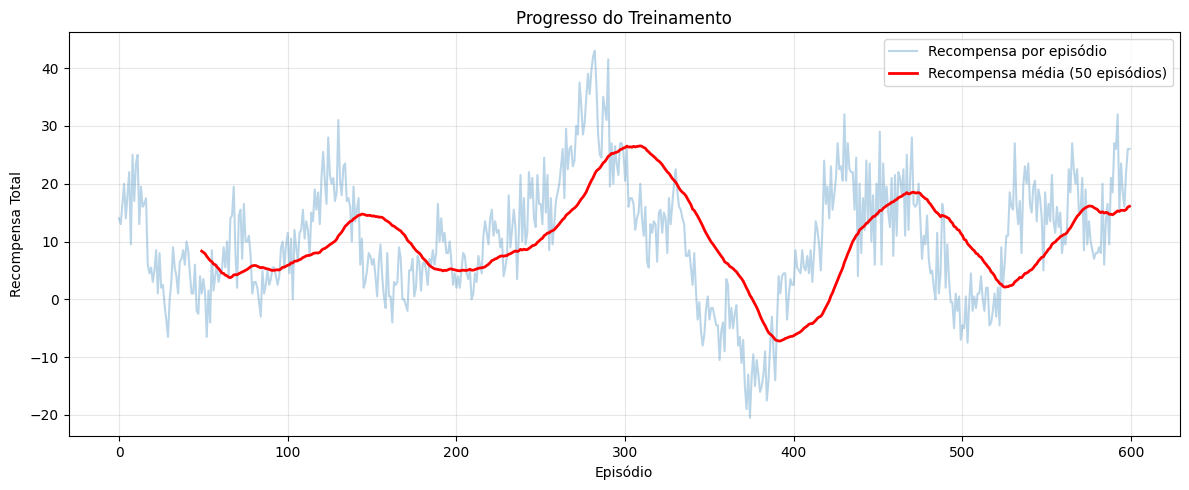


🎮 SIMULAÇÃO DE INTERAÇÕES EM TEMPO REAL

🔹 Interação 1:
   Recomendação: The Godfather (drama)
   Avaliação do usuário: 4.0/5 estrelas
   Histórico recente: ['The Godfather']
   ⏳⏳⏳ Pensando na próxima recomendação...⏳⏳⏳

🔹 Interação 2:
   Recomendação: The Conjuring (horror)
   Avaliação do usuário: 4.0/5 estrelas
   Histórico recente: ['The Godfather', 'The Conjuring']
   ⏳⏳⏳ Pensando na próxima recomendação...⏳⏳⏳

🔹 Interação 3:
   Recomendação: A Quiet Place (horror)
   Avaliação do usuário: 3.5/5 estrelas
   Histórico recente: ['The Godfather', 'The Conjuring', 'A Quiet Place']
   ⏳⏳⏳ Pensando na próxima recomendação...⏳⏳⏳

🔹 Interação 4:
   Recomendação: Fight Club (drama)
   Avaliação do usuário: 4.0/5 estrelas
   Histórico recente: ['The Conjuring', 'A Quiet Place', 'Fight Club']
   ⏳⏳⏳ Pensando na próxima recomendação...⏳⏳⏳

🔹 Interação 5:
   Recomendação: The Matrix (sci-fi)
   Avaliação do usuário: 1.0/5 estrelas
   Histórico recente: ['A Quiet Place', 'Fight Club', 'The Ma

In [4]:
import numpy as np
import random
from collections import defaultdict

# Configurações iniciais
GENRES = ['action', 'comedy', 'drama', 'horror', 'sci-fi']
MOVIES = {
    'action': ['The Dark Knight', 'Mad Max: Fury Road', 'John Wick', 'Die Hard', 'The Avengers'],
    'comedy': ['Superbad', 'The Hangover', 'Anchorman', 'Step Brothers', 'Bridesmaids'],
    'drama': ['The Shawshank Redemption', 'Forrest Gump', 'The Godfather', 'Pulp Fiction', 'Fight Club'],
    'horror': ['The Conjuring', 'Hereditary', 'Get Out', 'A Quiet Place', 'The Babadook'],
    'sci-fi': ['Inception', 'Interstellar', 'The Matrix', 'Blade Runner 2049', 'Arrival']
}

# Parâmetros do algoritmo
LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 0.9
EXPLORATION_RATE = 0.4
EXPLORATION_DECAY = 0.995
MAX_HISTORY_SIZE = 8

def initialize_user_preferences():
    """Inicializa as preferências do usuário"""
    return {
        'action': 0.8,
        'comedy': 0.6,
        'drama': 0.7,
        'horror': 0.3,
        'sci-fi': 0.9
    }

def get_state(user_preferences):
    """Calcula o estado baseado nas preferências médias"""
    avg_preference = np.mean(list(user_preferences.values()))
    return round(avg_preference * 10) / 10

def simulate_user_feedback(user_preferences, recommended_genre, recommended_movie):
    """Simula o feedback do usuário (0-5 estrelas)"""
    base_rating = user_preferences[recommended_genre] * 5
    # Menos ruído para feedback mais consistente
    noise = random.uniform(-0.8, 0.8)
    rating = max(0, min(5, base_rating + noise))
    return round(rating * 2) / 2  # Meias estrelas

def update_user_preferences(user_preferences, genre, rating):
    """Atualiza as preferências do usuário baseado no feedback"""
    user_preferences = user_preferences.copy()
    learning_rate = 0.15
    normalized_rating = rating / 5.0
    current_pref = user_preferences[genre]
    user_preferences[genre] = current_pref + learning_rate * (normalized_rating - current_pref)
    user_preferences[genre] = max(0.1, min(1.0, user_preferences[genre]))
    return user_preferences

def initialize_q_table():
    """Inicializa a tabela Q vazia"""
    return defaultdict(lambda: np.zeros(len(GENRES)))

def choose_action(q_table, state, exploration_rate, recent_recommendations):
    """Escolhe uma ação usando política ε-greedy, evitando repetições"""
    if random.random() < exploration_rate:
        # Exploração: ação aleatória, mas evitando gêneros muito recentes
        available_actions = list(range(len(GENRES)))
        
        # Remove gêneros recomendados nas últimas 2 interações
        if len(recent_recommendations) >= 2:
            recent_genres = [genre for genre, _ in recent_recommendations[-2:]]
            available_actions = [a for a in available_actions if GENRES[a] not in recent_genres]
        
        if available_actions:
            return random.choice(available_actions)
        else:
            return random.randint(0, len(GENRES) - 1)
    else:
        # Exploração: melhor ação conhecida, com diversificação
        q_values = q_table[state].copy()
        
        # Penaliza gêneros recomendados recentemente
        penalty = 3.0
        for i, (genre, _) in enumerate(recent_recommendations):
            if genre in GENRES:
                action_idx = GENRES.index(genre)
                # Penalização decrescente com o tempo
                q_values[action_idx] -= penalty / (i + 1)
        
        return np.argmax(q_values)

def update_q_table(q_table, state, action, reward, next_state, learning_rate, discount_factor):
    """Atualiza a tabela Q usando a equação do Q-learning"""
    best_next_action = np.argmax(q_table[next_state])
    td_target = reward + discount_factor * q_table[next_state][best_next_action]
    td_error = td_target - q_table[state][action]
    q_table[state][action] += learning_rate * td_error
    return q_table

def choose_movie(genre, watched_movies):
    """Escolhe um filme do gênero que não foi assistido recentemente"""
    available_movies = MOVIES[genre].copy()
    
    # Remove filmes assistidos recentemente (últimas 5 recomendações)
    recent_watched = watched_movies[-5:] if len(watched_movies) > 5 else watched_movies
    for watched_genre, watched_movie in recent_watched:
        if watched_genre == genre and watched_movie in available_movies:
            available_movies.remove(watched_movie)
    
    # Se todos os filmes foram assistidos recentemente, escolhe um menos recente
    if not available_movies and watched_movies:
        # Encontra o filme menos recente deste gênero
        genre_movies = [(movie, idx) for idx, (g, movie) in enumerate(watched_movies) if g == genre]
        if genre_movies:
            # Escolhe o filme que foi assistido há mais tempo
            oldest_movie = min(genre_movies, key=lambda x: x[1])[0]
            return oldest_movie
    
    return random.choice(available_movies) if available_movies else random.choice(MOVIES[genre])

def train_recommendation_system(episodes=500):
    """Treina o sistema de recomendação"""
    q_table = initialize_q_table()
    user_preferences = initialize_user_preferences()
    exploration_rate = EXPLORATION_RATE
    rewards_history = []
    
    # Histórico para evitar repetições
    recent_recommendations = []  # (gênero, filme)
    
    for episode in range(episodes):
        state = get_state(user_preferences)
        total_reward = 0
        steps = 0
        max_steps = 20  # Limite de passos por episódio
        
        while steps < max_steps:
            # Escolhe ação (gênero)
            action = choose_action(q_table, state, exploration_rate, recent_recommendations)
            recommended_genre = GENRES[action]
            
            # Escolhe filme específico
            recommended_movie = choose_movie(recommended_genre, recent_recommendations)
            
            # Executa ação e obtém feedback
            rating = simulate_user_feedback(user_preferences, recommended_genre, recommended_movie)
            reward = rating - 2.5  # Centraliza a recompensa
            
            # Atualiza preferências do usuário
            user_preferences = update_user_preferences(user_preferences, recommended_genre, rating)
            
            # Atualiza histórico de recomendações
            recent_recommendations.append((recommended_genre, recommended_movie))
            if len(recent_recommendations) > MAX_HISTORY_SIZE:
                recent_recommendations.pop(0)
            
            # Obtém próximo estado
            next_state = get_state(user_preferences)
            
            # Atualiza tabela Q
            q_table = update_q_table(
                q_table, state, action, reward, next_state, 
                LEARNING_RATE, DISCOUNT_FACTOR
            )
            
            state = next_state
            total_reward += reward
            steps += 1
        
        rewards_history.append(total_reward)
        exploration_rate *= EXPLORATION_DECAY
        
        if episode % 100 == 0:
            print(f"Episódio {episode}, Recompensa: {total_reward:.2f}, Exploração: {exploration_rate:.3f}")
    
    return q_table, user_preferences, rewards_history

def recommend_movie(q_table, user_preferences, recent_recommendations):
    """Faz uma recomendação baseada na política aprendida, evitando repetições"""
    state = get_state(user_preferences)
    q_values = q_table[state].copy()
    
    # Penaliza gêneros recomendados recentemente
    penalty = 4.0
    for i, (genre, _) in enumerate(recent_recommendations):
        if genre in GENRES:
            action_idx = GENRES.index(genre)
            # Penalização maior para recomendações mais recentes
            q_values[action_idx] -= penalty / (i + 1)
    
    best_action = np.argmax(q_values)
    recommended_genre = GENRES[best_action]
    recommended_movie = choose_movie(recommended_genre, recent_recommendations)
    
    return {
        'genre': recommended_genre,
        'movie': recommended_movie,
        'confidence': q_table[state][best_action],
        'state': state
    }

def get_diverse_recommendations(q_table, user_preferences, num_recommendations=5):
    """Gera um conjunto diversificado de recomendações sem repetição"""
    recommendations = []
    recent_history = []
    used_movies = set()
    
    for _ in range(num_recommendations * 3):  # Tentativas extras para garantir diversidade
        if len(recommendations) >= num_recommendations:
            break
            
        rec = recommend_movie(q_table, user_preferences, recent_history)
        
        # Verifica se o filme já foi recomendado
        if rec['movie'] not in used_movies:
            recommendations.append(rec)
            recent_history.append((rec['genre'], rec['movie']))
            used_movies.add(rec['movie'])
            
            # Limita o histórico para as recomendações atuais
            if len(recent_history) > 3:
                recent_history.pop(0)
    
    return recommendations[:num_recommendations]

def display_recommendations(q_table, user_preferences, num_recommendations=5):
    """Exibe recomendações diversificadas"""
    print("=" * 70)
    print("SISTEMA DE RECOMENDAÇÃO DE FILMES COM APRENDIZADO POR REFORÇO")
    print("=" * 70)
    
    print("\n📊 Preferências do usuário aprendidas:")
    for genre, pref in sorted(user_preferences.items(), key=lambda x: x[1], reverse=True):
        stars = "★" * int(pref * 5) + "☆" * (5 - int(pref * 5))
        print(f"  {genre:8}: {pref:.3f} {stars}")
    
    print(f"\n🎬 Top {num_recommendations} recomendações (diversificadas):")
    recommendations = get_diverse_recommendations(q_table, user_preferences, num_recommendations)
    
    for i, rec in enumerate(recommendations):
        print(f"  {i+1}. {rec['movie']:25} ({rec['genre']:6}) - Confiança: {rec['confidence']:7.3f}")
    
    # Mostra a Q-table para o estado médio
    avg_state = get_state(user_preferences)
    print(f"\n📈 Tabela Q para estado {avg_state}:")
    for i, genre in enumerate(GENRES):
        print(f"  {genre:8}: {q_table[avg_state][i]:7.3f}")

def plot_training_progress(rewards_history):
    """Plota o progresso do treinamento"""
    try:
        import matplotlib.pyplot as plt
        
        plt.figure(figsize=(12, 5))
        
        # Suaviza as recompensas para melhor visualização
        window_size = 50
        smoothed_rewards = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')
        
        plt.plot(rewards_history, alpha=0.3, label='Recompensa por episódio')
        plt.plot(range(window_size-1, len(rewards_history)), smoothed_rewards, 
                linewidth=2, label=f'Recompensa média ({window_size} episódios)', color='red')
        
        plt.title('Progresso do Treinamento')
        plt.xlabel('Episódio')
        plt.ylabel('Recompensa Total')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    except ImportError:
        print("Matplotlib não instalado. Pulando plotagem.")

def simulate_real_time_interactions(q_table, user_preferences, num_interactions=5):
    """Simula interações em tempo real com o usuário"""
    print("\n" + "=" * 70)
    print("🎮 SIMULAÇÃO DE INTERAÇÕES EM TEMPO REAL")
    print("=" * 70)
    
    recent_history = []
    
    for i in range(num_interactions):
        rec = recommend_movie(q_table, user_preferences, recent_history)
        recent_history.append((rec['genre'], rec['movie']))
        if len(recent_history) > 4:
            recent_history.pop(0)
        
        rating = simulate_user_feedback(user_preferences, rec['genre'], rec['movie'])
        
        print(f"\n🔹 Interação {i+1}:")
        print(f"   Recomendação: {rec['movie']} ({rec['genre']})")
        print(f"   Avaliação do usuário: {rating:.1f}/5 estrelas")
        print(f"   Histórico recente: {[movie for _, movie in recent_history[-3:]]}")
        
        # Atualiza preferências
        user_preferences = update_user_preferences(user_preferences, rec['genre'], rating)
        
        # Pequena pausa para dramatização
        if i < num_interactions - 1:
            print("   " + "⏳" * 3 + " Pensando na próxima recomendação..." + "⏳" * 3)

# Execução principal
if __name__ == "__main__":
    print("🎯 Iniciando treinamento do sistema de recomendação...")
    print(f"📁 Gêneros disponíveis: {', '.join(GENRES)}")
    print(f"🎬 Filmes por gênero: {sum(len(movies) for movies in MOVIES.values())} no total")
    print("-" * 70)
    
    # Treina o sistema
    print("🧠 Treinando o modelo com aprendizado por reforço...")
    q_table, user_preferences, rewards_history = train_recommendation_system(episodes=600)
    
    print("\n✅ Treinamento concluído!")
    print("-" * 70)
    
    # Exibe resultados
    display_recommendations(q_table, user_preferences, num_recommendations=8)
    
    # Plota progresso do treinamento
    plot_training_progress(rewards_history)
    
    # Simula interações em tempo real
    simulate_real_time_interactions(q_table, user_preferences, num_interactions=5)
    
    # Demonstração final com várias recomendações
    print("\n" + "=" * 70)
    print("🎉 DEMONSTRAÇÃO FINAL - RECOMENDAÇÕES DIVERSIFICADAS")
    print("=" * 70)
    
    final_recommendations = get_diverse_recommendations(q_table, user_preferences, 10)
    print("\nNossas melhores recomendações para você:")
    for i, rec in enumerate(final_recommendations):
        print(f"{i+1:2d}. {rec['movie']:25} ({rec['genre']:6}) [Conf: {rec['confidence']:6.2f}]")
    
    print(f"\n✨ Total de recomendações únicas: {len(set(rec['movie'] for rec in final_recommendations))}/10")
    print("🎊 Sistema de recomendação pronto para uso!")

In [20]:
# ======================================================================
# FIM DO PROGRAMA
# ======================================================================